# ¿Cuánto dura un foco? Una prueba acelerada explicada desde cero

**Ejercicio para principiantes con una pequeña interfaz Gradio**

Queremos entender una pregunta sencilla: si un foco se usa a un voltaje más alto que el indicado, ¿qué podría pasar con el tiempo que dura?

En una prueba de vida acelerada se prueban unidades bajo una condición más exigente para que las fallas aparezcan antes. En este ejemplo imaginaremos focos de **127 V** y usaremos el voltaje como condición de prueba. La respuesta que observamos será el número de horas hasta que el foco deja de encender.

Trabajaremos con datos creados por computadora. Al final, un control interactivo permitirá cambiar el voltaje y consultar la estimación.

> **Solo es un ejemplo de aprendizaje.** No conectes focos a voltajes mayores siguiendo este cuaderno. Una prueba real requiere laboratorio, equipo de protección y personal calificado. Las cifras no describen ningún foco comercial.

## Antes de empezar: la idea en palabras sencillas

Una prueba normal puede tomar mucho tiempo porque el foco trabaja en condiciones habituales. Para aprender más rápido, un laboratorio puede aplicar una condición más exigente y observar cómo cambia la duración.

En este cuaderno vamos a seguir cinco pasos:

1. Crear una lista de focos ficticios y de sus tiempos de falla.
2. Comparar cuánto duraron, en promedio, bajo cada nivel de voltaje simulado.
3. Usar una fórmula sencilla para relacionar voltaje y duración.
4. Calcular una estimación cuando cambiamos el voltaje.
5. Poner esa última acción en una interfaz Gradio.

**Una advertencia importante:** la fórmula solo sirve si el esfuerzo adicional adelanta el mismo tipo de falla que ocurre en el uso normal. El ejercicio no comprueba esa condición: la supone para poder enseñar el cálculo.

## Un poco más de teoría: qué hace una prueba de vida acelerada

Una prueba de vida acelerada estudia cuánto tarda un producto en fallar cuando se le aplica un esfuerzo más intenso que el habitual. El objetivo es aprender sobre su comportamiento sin esperar todo el tiempo que podría durar en uso normal.

### Las partes de una prueba

- **Producto:** las unidades que se ponen a prueba; aquí, focos.
- **Esfuerzo o condición de prueba:** aquello que puede acelerar el desgaste; en este ejemplo, el voltaje.
- **Condición de uso:** la condición normal con la que se compara; aquí, 127 V (100 %).
- **Falla:** el evento que marca el final de la vida. Para este ejercicio imaginamos que el foco ya no enciende. Un estudio real debe escribir esta regla con precisión.
- **Tiempo hasta falla:** cuánto tiempo pasó antes de que ocurriera esa falla.
- **Modelo de aceleración:** una regla matemática que conecta la condición severa con la condición normal.

### ¿Por qué no basta con subir el esfuerzo?

Subir el esfuerzo puede hacer que algo falle más rápido, pero no necesariamente enseña sobre el uso normal. La prueba debe acelerar el mismo tipo de daño que se busca estudiar. Por ejemplo, si el nivel severo produce un daño distinto al que ocurre en casa, la relación no sirve para predecir la vida normal.

Además, se prueban varias unidades porque los productos no son idénticos. Algunas pueden fallar antes y otras después. Un promedio resume el grupo, pero no describe cada unidad ni garantiza la vida de una unidad futura.

### ¿Qué es un modelo de aceleración?

El modelo de este cuaderno supone que la vida cambia con una **potencia inversa del voltaje**. En palabras sencillas: al aumentar el voltaje, la vida calculada disminuye. El número 8 de la fórmula controla cuánto disminuye.

En este ejemplo conocemos ese número porque lo elegimos al fabricar los datos. En una prueba auténtica no deberíamos escogerlo por conveniencia: habría que estimarlo con mediciones y revisar que el modelo describa el producto y el mecanismo de falla.

### Resultados que continúan funcionando

Si un ensayo termina y algunos focos todavía encienden, no sabemos su tiempo final de vida. Solo sabemos que duraron al menos hasta el final del ensayo. En confiabilidad se llaman observaciones **censuradas**. Este ejercicio las omite para mantener el primer ejemplo pequeño; un análisis real debe considerarlas.

## 1. Preparar las herramientas

Esta celda instala las herramientas que usaremos:

- `numpy` ayuda a crear números y a hacer cálculos.
- `pandas` organiza los datos en una tabla.
- `matplotlib` dibuja una gráfica.
- `gradio` crea el control interactivo del final.

En Google Colab, ejecuta esta celda una vez. Si ya tienes los paquetes, Colab puede indicar que están instalados.

In [22]:
%pip -q install numpy pandas matplotlib gradio

**Qué significa la salida:** si la celda termina sin un mensaje de error, podemos continuar. Las líneas de instalación que aparecen en pantalla son mensajes de trabajo normales.

## 2. Cargar las herramientas

Ahora importamos las bibliotecas para poder usarlas. Les damos nombres cortos para que el código sea más fácil de leer. La última línea avisa que la preparación terminó.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr

np.random.seed(42)
print("Listo: las herramientas ya se pueden usar.")

Listo: las herramientas ya se pueden usar.


**Salida esperada:** `Listo: las herramientas ya se pueden usar.`. La semilla `42` hace que los números aleatorios del ejemplo se repitan de la misma forma cada vez que ejecutemos el cuaderno.

## 3. Definir las condiciones del ejemplo

Tomaremos 127 voltios como el valor normal o nominal del foco. Vamos a imaginar tres grupos de prueba: 100 %, 110 % y 120 % de ese valor.

Por ejemplo, 110 % significa un valor simulado mayor que el nominal. Recuerda: no apliques estos voltajes a focos reales; aquí solo son números para aprender.

In [24]:
voltaje_normal = 127
porcentajes = [100, 110, 120]
focos_por_grupo = 8

print(f"Voltaje normal del ejemplo: {voltaje_normal} V")
print("Cada porcentaje corresponde a este voltaje:")
for porcentaje in porcentajes:
    voltaje = voltaje_normal * porcentaje / 100
    print(f"  {porcentaje}% = {voltaje:.1f} V")
print(f"Total planeado: {len(porcentajes) * focos_por_grupo} focos ficticios")

Voltaje normal del ejemplo: 127 V
Cada porcentaje corresponde a este voltaje:
  100% = 127.0 V
  110% = 139.7 V
  120% = 152.4 V
Total planeado: 24 focos ficticios


**Interpretación de la salida:** 100 % corresponde al valor normal del ejemplo (127 V). Los otros valores son 139.7 V y 152.4 V, calculados solo para simular condiciones más severas. Ocho focos por cada una de las tres condiciones dan 24 focos en total. No uses estos voltajes en un ensayo real.

## 4. Crear datos ficticios

Primero calculamos el voltaje de cada grupo a partir del porcentaje. Después generamos un tiempo de vida simulado para cada foco.

Para hacer el ejemplo fácil, elegimos una regla conocida: en el voltaje normal imaginamos una duración media de 8,000 horas; al aumentar el voltaje, la duración baja. También agregamos pequeñas diferencias entre focos para que no todos tengan el mismo resultado.

**Importante:** en un experimento real no conoceríamos de antemano la duración media ni la regla completa. Aquí elegimos esos valores para fabricar datos de práctica.

In [25]:
registros = []
vida_normal_ejemplo = 8000

for porcentaje in porcentajes:
    voltaje = voltaje_normal * porcentaje / 100
    proporcion = porcentaje / 100
    vida_media = vida_normal_ejemplo / (proporcion ** 8)

    # Creamos ocho resultados cercanos al promedio de este grupo.
    variaciones = np.random.normal(loc=1, scale=0.08, size=focos_por_grupo)

    for numero, variacion in enumerate(variaciones, start=1):
        horas = vida_media * variacion
        registros.append([porcentaje, voltaje, numero, round(horas)])

datos = pd.DataFrame(
    registros,
    columns=["porcentaje", "voltaje_V", "numero_foco", "horas_hasta_falla"]
)
print("Se crearon", len(datos), "resultados ficticios.")

Se crearon 24 resultados ficticios.


**Qué hizo el código:** recorrió cada porcentaje, calculó su voltaje y preparó ocho resultados. `registros` guarda los resultados; al final `pandas` los convierte en una tabla llamada `datos`.

**Salida esperada:** `Se crearon 24 resultados ficticios.` (3 grupos × 8 focos). Las horas no vienen de una prueba real: se generaron con una regla que definimos para este ejercicio.

**Interpretación de las salidas:** arriba aparecen seis ejemplos de focos. `porcentaje` indica el nivel de prueba; `voltaje_V`, el voltaje simulado; `numero_foco`, el número de unidad dentro de ese grupo; y `horas_hasta_falla`, la duración que inventó el programa.

El resumen inferior muestra cuántas filas hay (`count`), el promedio (`mean`), la desviación típica (`std`) y los valores menor (`min`) y mayor (`max`). `count` debe ser 24. La desviación indica cuánto varían las horas entre unidades; no es una tolerancia ni una garantía.

In [26]:
print("Primeros seis focos de la tabla:")
display(datos.head(6))
print("\nResumen rápido de las horas simuladas:")
print(datos["horas_hasta_falla"].describe().round(0))

Primeros seis focos de la tabla:


,porcentaje,voltaje_V,numero_foco,horas_hasta_falla
0,100,127.0,1,8318
1,100,127.0,2,7912
2,100,127.0,3,8415
3,100,127.0,4,8975
4,100,127.0,5,7850
5,100,127.0,6,7850



Resumen rápido de las horas simuladas:
count      24.0
mean     4569.0
std      2845.0
min      1648.0
25%      1898.0
50%      3592.0
75%      7866.0
max      9011.0
Name: horas_hasta_falla, dtype: float64


**Cómo leer la tabla:** `porcentaje` indica la condición; `voltaje_V` muestra el voltaje equivalente; `numero_foco` identifica la unidad dentro de su grupo, y `horas_hasta_falla` contiene la duración simulada. Las filas iniciales pertenecen al grupo de 100 % porque los grupos se agregaron en ese orden.

## 6. Comparar la duración promedio

Los focos de un mismo grupo no duran exactamente lo mismo. Para hacer una comparación sencilla, calculamos el promedio de horas para cada nivel de voltaje.

El promedio suma las duraciones del grupo y las divide entre el número de focos. Nos ayuda a resumir ocho valores en una cifra fácil de comparar.

In [27]:
resumen = datos.groupby("porcentaje").agg(
    voltaje_V=("voltaje_V", "first"),
    promedio_h=("horas_hasta_falla", "mean"),
    minimo_h=("horas_hasta_falla", "min"),
    maximo_h=("horas_hasta_falla", "max"),
    focos=("horas_hasta_falla", "count")
).round(0).astype(int)

# Comparamos cada grupo con el promedio del grupo de voltaje normal.
promedio_normal = resumen.loc[100, "promedio_h"]
resumen["cambio_vs_100_pct"] = ((resumen["promedio_h"] / promedio_normal - 1) * 100).round(1)
resumen

,voltaje_V,promedio_h,minimo_h,maximo_h,focos,cambio_vs_100_pct
porcentaje,,,,,,
100,127,8353,7850,9011,8,0.0
110,140,3552,3161,3894,8,-57.5
120,152,1802,1648,2079,8,-78.4


**Interpretación de la tabla:** cada fila resume un grupo. `voltaje_V` es el valor simulado en voltios; `promedio_h` es la duración media; `minimo_h` y `maximo_h` muestran el foco más corto y más largo del grupo; `focos` indica cuántas unidades se usaron.

`cambio_vs_100_pct` compara el promedio con el grupo de 100 %. Un número negativo significa que ese grupo duró menos en la simulación; por ejemplo, −20 % significa un promedio 20 % menor. La comparación describe estos datos ficticios y no permite afirmar que todos los focos de ese voltaje se comporten igual.

## 7. Dibujar los promedios

Una gráfica permite ver la comparación rápidamente. En el eje horizontal está el porcentaje de voltaje. En el eje vertical están las horas promedio. Cada barra corresponde a un grupo.

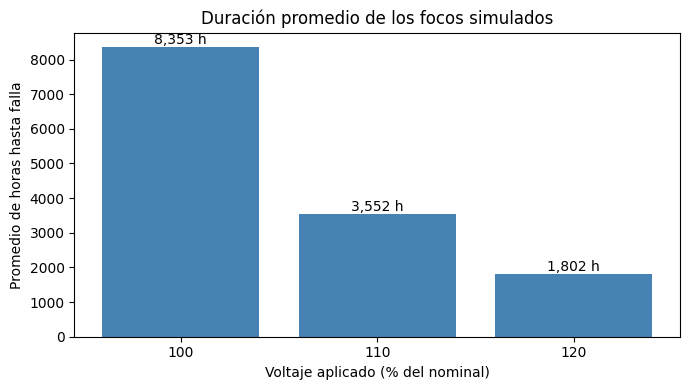

In [28]:
plt.figure(figsize=(7, 4))
barras = plt.bar(resumen.index.astype(str), resumen["promedio_h"], color="steelblue")
plt.title("Duración promedio de los focos simulados")
plt.xlabel("Voltaje aplicado (% del nominal)")
plt.ylabel("Promedio de horas hasta falla")

# Escribimos el promedio encima de cada barra para facilitar la lectura.
for barra, promedio in zip(barras, resumen["promedio_h"]):
    plt.text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
             f"{promedio:,.0f} h", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Interpretación de la gráfica:** cada barra corresponde al promedio de ocho focos. La etiqueta sobre la barra muestra las horas aproximadas. Compara primero la barra de 100 % con las de 110 % y 120 %: en los datos simulados, las barras tienden a bajar al aumentar el voltaje.

La gráfica sirve para ver una tendencia general. No muestra todos los focos por separado; para eso revisamos la tabla. Y como los datos fueron creados por computadora, la tendencia era parte del ejercicio, no un hallazgo de laboratorio.

## 8. La fórmula de estimación

Usaremos una regla matemática muy sencilla:

**vida estimada = vida normal del ejemplo ÷ (porcentaje del voltaje elevado a 8)**

En código, expresamos los porcentajes como proporciones: 100 % se escribe `1.00`, 110 % se escribe `1.10` y 120 % se escribe `1.20`.

El número `8` indica cuánto se reduce la duración cuando aumenta el voltaje. Lo fijamos nosotros para construir el ejercicio; no lo aprendimos de mediciones. En un estudio real se tendría que estimar con datos apropiados y revisar que el modelo sea válido.

In [29]:
def estimar_horas(porcentaje):
    proporcion = porcentaje / 100
    return vida_normal_ejemplo / (proporcion ** 8)

for porcentaje in [100, 110, 120]:
    horas = estimar_horas(porcentaje)
    cambio = (horas / vida_normal_ejemplo - 1) * 100
    print(f"Al {porcentaje}%: {horas:,.0f} horas estimadas ({cambio:+.1f}% frente a 100%).")

Al 100%: 8,000 horas estimadas (+0.0% frente a 100%).
Al 110%: 3,732 horas estimadas (-53.3% frente a 100%).
Al 120%: 1,861 horas estimadas (-76.7% frente a 100%).


**Interpretación de la salida:** 100 % devuelve 8,000 horas porque ese número se usó como vida de referencia al crear el ejemplo. A 110 % y 120 %, la fórmula entrega cada vez menos horas. El porcentaje entre paréntesis expresa cuánto cambia el cálculo frente a 100 %; un valor negativo indica reducción.

La fórmula no se ajustó ni aprendió a partir de la tabla. Usamos la misma regla para crear los datos y para calcular las estimaciones. Esto hace el ejercicio fácil de seguir, pero en una prueba real hay que estimar y comprobar la regla con mediciones.

## 9. Probar otro valor

Podemos llamar a la misma función con otros porcentajes. La siguiente celda muestra la estimación en horas y también la convierte a años de uso continuo.

Para convertir horas a años dividimos entre 24 horas por día y unos 365 días por año. Es solo una conversión: supone que el foco está encendido sin parar.

In [30]:
porcentaje_consulta = 115
horas_consulta = estimar_horas(porcentaje_consulta)
anios_continuos = horas_consulta / (24 * 365)

promedio_normal = resumen.loc[100, "promedio_h"]
diferencia_h = promedio_normal - horas_consulta
reduccion_pct = diferencia_h / promedio_normal * 100

print(f"Condición consultada: {porcentaje_consulta}% del voltaje normal.")
print(f"Voltaje equivalente: {voltaje_normal * porcentaje_consulta / 100:.1f} V.")
print(f"Vida calculada por la fórmula: {horas_consulta:,.0f} horas.")
print(f"Equivalencia si funcionara sin parar: {anios_continuos:.2f} años.")
print(f"Frente al promedio simulado al 100% ({promedio_normal:,.0f} h),")
print(f"la fórmula calcula {diferencia_h:,.0f} horas menos, una reducción aproximada de {reduccion_pct:.1f}%.")

Condición consultada: 115% del voltaje normal.
Voltaje equivalente: 146.1 V.
Vida calculada por la fórmula: 2,615 horas.
Equivalencia si funcionara sin parar: 0.30 años.
Frente al promedio simulado al 100% (8,353 h),
la fórmula calcula 5,738 horas menos, una reducción aproximada de 68.7%.


**Interpretación de la salida:** el programa convierte 115 % a voltios, calcula las horas con la fórmula y transforma esas horas a años suponiendo funcionamiento continuo. También compara la estimación con el promedio simulado del grupo de 100 % y expresa la diferencia en horas y porcentaje.

Esta comparación ayuda a poner el número en contexto. No significa que un foco real vaya a durar ese tiempo: es una consecuencia de la fórmula y los valores inventados.

## 10. Crear una interfaz sencilla con Gradio

Ahora pondremos la función detrás de un control visual. La persona podrá mover un deslizador y ver cuántas horas estima la fórmula.

En Google Colab usamos `share=True` para crear un enlace temporal que conecte el navegador con la aplicación. Mientras la sesión de Colab permanezca activa, se puede usar ese enlace. Compártelo solo con las personas que deban acceder.

In [31]:
def mostrar_estimacion(porcentaje):
    horas = estimar_horas(porcentaje)
    anios = horas / (24 * 365)
    horas_normales = estimar_horas(100)
    reduccion_pct = (1 - horas / horas_normales) * 100
    voltaje = voltaje_normal * porcentaje / 100

    return (
        f"Condición elegida: {porcentaje:.0f}% ({voltaje:.1f} V).\n"
        f"Duración calculada: {horas:,.0f} horas, o {anios:.2f} años de uso continuo.\n"
        f"Cambio frente al cálculo a 100%: {reduccion_pct:.1f}% menos.\n\n"
        "Interpretación: al subir el voltaje, esta fórmula calcula menos horas.\n"
        "Ejercicio educativo: datos y regla ficticios; no predice ni garantiza la vida de un foco real."
    )

interfaz = gr.Interface(
    fn=mostrar_estimacion,
    inputs=gr.Slider(100, 120, value=100, step=1,
                     label="Voltaje como porcentaje del nominal"),
    outputs=gr.Textbox(label="Estimación e interpretación", lines=7),
    title="Estimador educativo de duración de un foco",
    description="Mueve el control para ver el cálculo. Datos ficticios; solo para aprender."
)
interfaz.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5cdecc6bd757280319.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Qué verás en Gradio:** un deslizador de 100 % a 120 %. La salida mostrará el voltaje equivalente, las horas, la conversión a años de uso continuo y el cambio frente al cálculo de 100 %. También incluye una frase que explica la dirección del resultado y recuerda que es ficticio.

Si Colab muestra un enlace temporal, ábrelo para consultar la interfaz. El enlace funciona mientras la sesión esté activa.

## 11. Conclusiones

1. Una prueba de vida acelerada usa condiciones más exigentes para estudiar fallas en menos tiempo.
2. En nuestro ejemplo, el voltaje es la condición acelerante y las horas hasta que el foco deja de funcionar son el resultado.
3. Los datos y la fórmula son ficticios; se prepararon para practicar tablas, promedios, una gráfica y una función.
4. La fórmula enseña una idea: si el voltaje sube, el tiempo estimado baja. No demuestra cuánto dura un foco real.
5. Un estudio real necesita mediciones, un plan de ensayo seguro, una definición clara de falla y un modelo validado para el tipo de foco estudiado.

**En resumen:** el ejercicio permite entender el recorrido desde unos datos hasta una estimación interactiva. La interfaz hace más fácil probar valores, pero no vuelve reales ni certificadas las cifras simuladas.

## Vocabulario rápido

- **Vida útil:** tiempo que transcurre antes de que ocurra la falla definida.
- **Voltaje nominal:** valor eléctrico para el que se diseñó el ejemplo del producto; aquí usamos 127 V.
- **Acelerante:** condición que aumenta el ritmo de aparición de fallas durante el ensayo.
- **Promedio:** suma de varios resultados dividida entre cuántos resultados hay.
- **Extrapolar:** usar un modelo para estimar una condición que no se midió directamente.
- **Dato simulado:** número creado por un programa, no observado en un laboratorio.